**HR Analytics: Employee Attrition Analysis**

Project Overview

This project analyses employee attrition using HR data to identify the factors associated with employee turnover. The analysis includes data cleaning, exploratory data analysis (EDA), visualisations and business insights.

In [1]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Mount Google Drive to access the dataset stored there

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Load the HR dataset into a DataFrame for analysis

df = pd.read_csv('/content/drive/MyDrive/HR_Analytics.csv')
print("Data loaded successfully.")

Data loaded successfully.


**EDA (Exploratory Data Analysis)**


In [4]:
df.shape

# 1480 rows, 38 columns — a mid-sized HR dataset, one row per employee


(1480, 38)

In [ ]:
# Exploring top 5 rows

df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

In [ ]:
# Exploring data types

df.dtypes

,0
EmpID,object
Age,int64
AgeGroup,object
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object


In [ ]:
df.isnull().sum()

#Only one column has missing data: YearsWithCurrManager (57 missing values, ~4% of rows)


,0
EmpID,0
Age,0
AgeGroup,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0


In [ ]:
df.duplicated().sum()

# 7 fully duplicated rows found — these need to be removed before analysis


np.int64(7)

In [ ]:
for col in df.columns:
  print(col)

EmpID
Age
AgeGroup
Attrition
BusinessTravel
DailyRate
Department
DistanceFromHome
Education
EducationField
EmployeeCount
EmployeeNumber
EnvironmentSatisfaction
Gender
HourlyRate
JobInvolvement
JobLevel
JobRole
JobSatisfaction
MaritalStatus
MonthlyIncome
SalarySlab
MonthlyRate
NumCompaniesWorked
Over18
OverTime
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StandardHours
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager


In [ ]:
df.select_dtypes(include='object').columns


Index(['EmpID', 'AgeGroup', 'Attrition', 'BusinessTravel', 'Department',
       'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'SalarySlab',
       'Over18', 'OverTime'],
      dtype='object')

In [ ]:
#Checking categories for unique values

df['Department'].unique()

array(['Research & Development', 'Sales', 'Human Resources'], dtype=object)

In [ ]:
df['Attrition'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Education'].unique()

array([3, 2, 1, 4, 5])

In [ ]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df['JobRole'].unique()

array(['Laboratory Technician', 'Sales Representative',
       'Research Scientist', 'Human Resources', 'Manufacturing Director',
       'Sales Executive', 'Healthcare Representative',
       'Research Director', 'Manager'], dtype=object)

In [ ]:
df['OverTime'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1480.0,36.917568,9.128559,18.0,30.00,36.0,43.00,60.0
DailyRate,1480.0,801.384459,403.126988,102.0,465.00,800.0,1157.00,1499.0
DistanceFromHome,1480.0,9.220270,8.131201,1.0,2.00,7.0,14.00,29.0
Education,1480.0,2.910811,1.023796,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1480.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1480.0,1031.860811,605.955046,1.0,493.75,1027.5,1568.25,2068.0
EnvironmentSatisfaction,1480.0,2.724324,1.092579,1.0,2.00,3.0,4.00,4.0
HourlyRate,1480.0,65.845270,20.328266,30.0,48.00,66.0,83.00,100.0
JobInvolvement,1480.0,2.729730,0.713007,1.0,2.00,3.0,3.00,4.0
JobLevel,1480.0,2.064865,1.105574,1.0,1.00,2.0,3.00,5.0


**Data Cleaning**

In [ ]:
#Create a copy before cleaning data
df_clean = df.copy()

In [ ]:
df[df.duplicated(keep=False)]

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
210,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0
211,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0
327,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
328,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
457,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
458,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
654,RM1470,34,26-35,No,TravelRarely,628,Research & Development,8,3,Medical,...,1,80,0,6,3,4,4,3,1,2.0
655,RM1470,34,26-35,No,TravelRarely,628,Research & Development,8,3,Medical,...,1,80,0,6,3,4,4,3,1,2.0
952,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
954,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0


In [ ]:
# Removing the duplicates
df_clean = df.drop_duplicates()

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
#Exploring the column with missing values

df_clean[df_clean["YearsWithCurrManager"].isnull()]

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
28,RM024,21,18-25,No,Travel_Rarely,391,Research & Development,15,2,Life Sciences,...,4,80,0,0,6,3,0,0,0,NaN
31,RM363,21,18-25,No,Non-Travel,895,Sales,9,2,Medical,...,3,80,0,3,3,2,3,2,2,NaN
45,RM207,22,18-25,No,Travel_Rarely,1136,Research & Development,5,3,Life Sciences,...,1,80,1,4,2,2,4,2,2,NaN
99,RM139,25,18-25,No,Travel_Rarely,959,Sales,28,3,Life Sciences,...,4,80,0,6,3,3,2,2,2,NaN
100,RM256,25,18-25,No,Travel_Rarely,685,Research & Development,1,3,Life Sciences,...,4,80,2,5,3,3,4,2,1,NaN
103,RM406,25,18-25,Yes,Travel_Rarely,688,Research & Development,3,3,Medical,...,3,80,1,6,5,3,2,2,0,NaN
222,RM405,28,26-35,No,Travel_Rarely,1300,Research & Development,17,2,Medical,...,4,80,1,10,2,3,10,0,1,NaN
262,RM072,29,26-35,No,Travel_Rarely,1328,Research & Development,2,3,Life Sciences,...,4,80,1,6,3,3,5,4,0,NaN
264,RM206,29,26-35,Yes,Travel_Rarely,121,Sales,27,3,Marketing,...,4,80,3,10,3,2,10,4,1,NaN
268,RM253,29,26-35,No,Travel_Rarely,665,Research & Development,15,3,Life Sciences,...,1,80,0,6,1,3,6,5,1,NaN


In [ ]:
df_clean['YearsWithCurrManager'].describe()

,YearsWithCurrManager
count,1416.000000
mean,4.117232
std,3.559344
min,0.000000
25%,2.000000
50%,3.000000
75%,7.000000
max,17.000000


In [ ]:
#Calculating the median value
df_clean["YearsWithCurrManager"].median()

3.0

In [ ]:
#Filling in missing values with median value

df_clean["YearsWithCurrManager"] = df_clean["YearsWithCurrManager"].fillna(
        df_clean["YearsWithCurrManager"].median())

# Used median rather than mean because tenure data is often right-skewed
# (a few long-tenured employees would inflate the mean), so median is more robust

In [ ]:
df_clean.isnull().sum()

,0
EmpID,0
Age,0
AgeGroup,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0


**Visualisations**

In [ ]:
# How many employees left the company and how many stayed
df_clean['Attrition'].value_counts()

,count
Attrition,
No,1242
Yes,238


In [ ]:
#Attrition Rate
attrition_rate = ((df_clean["Attrition"] == "Yes").mean() * 100).round(1)
print(f"Attrition Rate: {attrition_rate:.1f}%")


Attrition Rate: 16.1%


In [ ]:
#Which department has the highest employee turnover?"

department_total=df_clean.groupby('Department').size()

department_attrition = df_clean[df_clean["Attrition"] == "Yes"].groupby("Department").size()

department_attrition_rate = (department_attrition / department_total * 100).round(1).sort_values(ascending=False)

print(department_attrition_rate)



Department
Sales                     20.7
Human Resources           19.0
Research & Development    13.8
dtype: float64


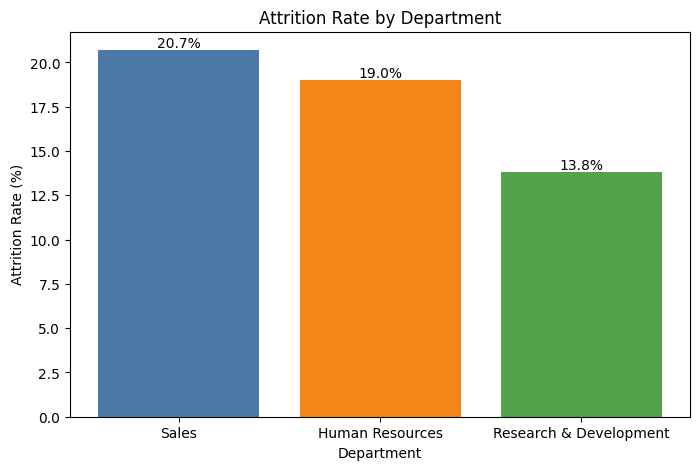

In [ ]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    x=department_attrition_rate.index,
    height=department_attrition_rate.values, color=["#4C78A8", "#F58518", "#54A24B"]
)

plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Department")

plt.bar_label(bars, labels=department_attrition_rate.astype(str) + "%")

plt.show()

**Insights**

Sales has the highest attrition rate (20.7%), followed by HR (19.0%). R&D has the lowest attrition rate (13.8%).


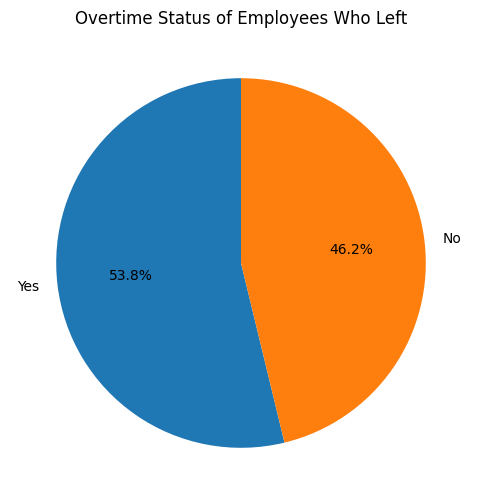

In [ ]:
#Is attrition influenced by overtime
overtime_left = df_clean[df_clean["Attrition"] == "Yes"]["OverTime"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    overtime_left,
    labels=overtime_left.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overtime Status of Employees Who Left")

plt.show()


**Insights**

Slightly more employees who left had worked overtime than had not. This suggests overtime may be one of the factors influencing attrition.

In [ ]:
#Attrition by Job Satisfaction

job_satisfaction_attrition = df_clean[df_clean["Attrition"] == "Yes"].groupby("JobSatisfaction").size()
job_satisfaction_attrition

,0
JobSatisfaction,
1,67
2,46
3,73
4,52


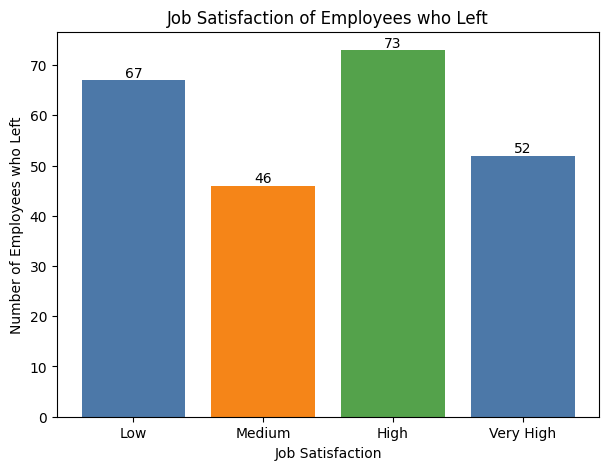

In [ ]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    x=job_satisfaction_attrition.index,
    height=job_satisfaction_attrition.values,
   color=["#4C78A8", "#F58518", "#54A24B"]
)

plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees who Left")
plt.title("Job Satisfaction of Employees who Left")
plt.xticks([1, 2, 3, 4], ["Low", "Medium", "High", "Very High"])

plt.bar_label(bars)

plt.show()

**Insights**

Employee attrition is distributed across all job satisfaction levels, with no clear pattern indicating that lower job satisfaction is associated with a higher number of employees leaving.

In [ ]:
# Attrition by years in the company

df_clean["TenureGroup"] = pd.cut(df_clean["YearsAtCompany"],
    bins=[0, 2, 5, 10, 20, 40],
    labels=["0-2", "3-5", "6-10", "11-20", "21-40"],
    include_lowest=True
)
tenure_attrition = (df_clean[df_clean["Attrition"] == "Yes"].groupby("TenureGroup").size())

print(tenure_attrition)

TenureGroup
0-2      102
3-5       61
6-10      55
11-20     12
21-40      8
dtype: int64


/tmp/ipykernel_3918/3033567822.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_attrition = (df_clean[df_clean["Attrition"] == "Yes"].groupby("TenureGroup").size())


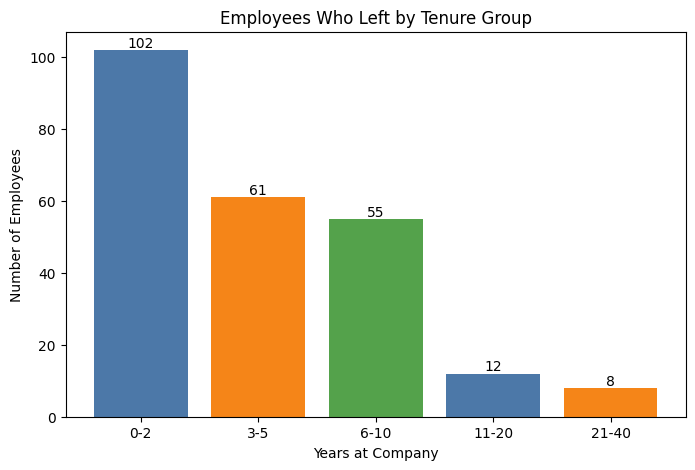

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    tenure_attrition.index,
    tenure_attrition.values,
    color=["#4C78A8", "#F58518", "#54A24B"]
)

plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.title("Employees Who Left by Tenure Group")

plt.bar_label(bars)

plt.show()


**Insights**

Most employees who left had relatively short tenure with the company. This suggests attrition is highest during the early years of employment, highlighting the importance of effective onboarding and early employee engagement.

**General Insights**


*Note: This analysis explores a selected set of factors associated with employee attrition—department, overtime, job satisfaction, and tenure—rather than every variable in the dataset. Other factors, such as monthly income, distance from home, work-life balance, or job role, could be explored in future analysis.*

-The overall attrition rate is 16.1%.

-Sales has the highest departmental attrition rate (20.7%), followed by Human Resources (19.0%) and Research & Development (13.8%).

-A larger proportion of employees who left the company had worked overtime, suggesting that overtime may be associated with employee attrition.

-Employees with 0–2 years of service represent the largest group of employees who left, indicating that attrition is highest during the early stages of employment.

-Job satisfaction does not show a clear relationship with attrition. Employees who left are distributed across all satisfaction levels, suggesting that job satisfaction alone is not a strong predictor of employee turnover in this dataset.
  